In [1]:
import numpy as np
import pandas as pd
import tidyfinance as tf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
import pandas as pd
import pandas_datareader as pdr

In [2]:

# ── Configuration ──────────────────────────────────────────────────────────────
START = "2000-01-01"
END   = "2025-05-01"

REGIMES = {
    "Dot-com crash" : ("2000-01-01", "2002-10-09"),
    "Recovery"      : ("2002-10-10", "2007-12-31"),
    "GFC"           : ("2008-01-01", "2009-12-31"),
    "Recovery/ZIRP" : ("2010-01-01", "2015-12-31"),
    "Pre-COVID"     : ("2016-01-01", "2019-12-31"),
    "COVID"         : ("2020-01-01", "2021-12-31"),
    "Rate cycle"    : ("2022-01-01", "2022-12-31"),
    "Regional banks": ("2023-03-01", "2023-05-31"),
    "Post-crisis"   : ("2023-06-01", "2025-05-01"),
}

PORTFOLIO_TICKERS = {
    "Mega Tech" : ["AAPL", "MSFT", "NVDA", "AMZN", "GOOG", "META", "AVGO", "TSLA"],
    "Energy"    : ["XOM", "CVX", "COP", "EOG", "SLB", "NEE", "DUK", "CEG", "SO", "D"],
    "FMCG"      : ["WMT", "COST", "TGT", "PG", "UL", "KMB", "KO", "PEP", "NSRGY", "GIS"],
}

# ── Data Ingestion ─────────────────────────────────────────────────────────────
all_equity = (
    ["IEF", "^VIX", "VNQ"] +
    [t for tickers in PORTFOLIO_TICKERS.values() for t in tickers]
)

print("Downloading price data...")
raw_prices = yf.download(all_equity, start=START, end=END)["Close"]
raw_prices.columns.name = None

print("Downloading risk-free rate...")
irx      = yf.download("^IRX", start=START, end=END)["Close"].squeeze().dropna() / 100
rf_daily = irx / 252

print("\nFirst valid date per ticker:")
print(raw_prices.apply(lambda x: x.first_valid_index()))


[*********************100%***********************]  31 of 31 completed
[*********************100%***********************]  1 of 1 completed


First valid date per ticker:
AAPL    2000-01-03
AMZN    2000-01-03
AVGO    2009-08-06
CEG     2022-01-19
COP     2000-01-03
COST    2000-01-03
CVX     2000-01-03
D       2000-01-03
DUK     2000-01-03
EOG     2000-01-03
GIS     2000-01-03
GOOG    2004-08-19
IEF     2002-07-30
KMB     2000-01-03
KO      2000-01-03
META    2012-05-18
MSFT    2000-01-03
NEE     2000-01-03
NSRGY   2000-01-03
NVDA    2000-01-03
PEP     2000-01-03
PG      2000-01-03
SLB     2000-01-03
SO      2000-01-03
TGT     2000-01-03
TSLA    2010-06-29
UL      2000-01-03
VNQ     2004-09-29
WMT     2000-01-03
XOM     2000-01-03
^VIX    2000-01-03
dtype: datetime64[ns]


In [3]:
# ── Portfolio Constructors ─────────────────────────────────────────────────────
def build_dynamic_equal_weight(prices_df, tickers):
    """Equal weight across available stocks each day -- adjusts as IPOs enter."""
    rets      = prices_df[tickers].pct_change()
    available = rets.notna()
    weights   = available.div(available.sum(axis=1), axis=0).fillna(0)
    port_ret  = (rets.fillna(0) * weights).sum(axis=1)
    port_ret  = port_ret[available.sum(axis=1) > 0]
    return port_ret, available

def build_fixed_weight(prices_df, weight_dict):
    """Fixed weights from inception -- used for barbell."""
    tickers = list(weight_dict.keys())
    rets    = prices_df[tickers].pct_change().dropna()
    return rets.dot(pd.Series(weight_dict)), None

def build_single_etf(prices_df, ticker):
    """Single ETF -- no weighting logic needed."""
    rets = prices_df[ticker].pct_change().dropna()
    return rets, None

# ── Build All Portfolios ───────────────────────────────────────────────────────
barbell_ret,  _              = build_fixed_weight(raw_prices, {"IEF": 0.95, "^VIX": 0.05})
vnq_ret,      _              = build_single_etf(raw_prices, "VNQ")
tech_ret,     tech_avail     = build_dynamic_equal_weight(raw_prices, PORTFOLIO_TICKERS["Mega Tech"])
energy_ret,   energy_avail   = build_dynamic_equal_weight(raw_prices, PORTFOLIO_TICKERS["Energy"])
fmcg_ret,     fmcg_avail     = build_dynamic_equal_weight(raw_prices, PORTFOLIO_TICKERS["FMCG"])

portfolios = {
    "Barbell"   : (barbell_ret, None),
    "Mega Tech" : (tech_ret,    tech_avail),
    "Energy"    : (energy_ret,  energy_avail),
    "REIT (VNQ)": (vnq_ret,     None),
    "FMCG"      : (fmcg_ret,    fmcg_avail),
}

In [4]:
# ── Metrics ────────────────────────────────────────────────────────────────────
def sharpe_ratio(pr, rf, periods=252):
    excess = pr - rf
    return (excess.mean() / excess.std()) * np.sqrt(periods)

def sortino_ratio(pr, rf, periods=252):
    excess   = pr - rf
    downside = excess[excess < 0].std() * np.sqrt(periods)
    return (excess.mean() * periods) / downside

# ── Regime Analysis ────────────────────────────────────────────────────────────
def regime_table(name, port_returns, available=None):
    print(f"\n{'=' * 72}")
    print(f"  {name}")
    print(f"{'=' * 72}")

    has_n = available is not None
    header = f"  {'Regime':<20} {'N':>4}  " if has_n else f"  {'Regime':<20}  "
    header += f"{'Sharpe':>7}  {'Sortino':>8}  {'Ann.Ret':>8}  {'Ann.Vol':>8}"
    print(header)
    print(f"  {'-' * 68}")

    for label, (start, end) in REGIMES.items():
        pr = port_returns.loc[start:end]
        rf = rf_daily.reindex(pr.index, method="ffill")

        if len(pr) < 20:
            print(f"  {label:<20}  -- insufficient data (n={len(pr)})")
            continue

        sr      = sharpe_ratio(pr, rf)
        so      = sortino_ratio(pr, rf)
        ann_ret = pr.mean() * 252
        ann_vol = pr.std() * np.sqrt(252)

        if has_n:
            n = available.loc[start:end].sum(axis=1).mean()
            print(f"  {label:<20} {n:>4.1f}  {sr:>7.3f}  {so:>8.3f}  {ann_ret:>8.2%}  {ann_vol:>8.2%}")
        else:
            print(f"  {label:<20}        {sr:>7.3f}  {so:>8.3f}  {ann_ret:>8.2%}  {ann_vol:>8.2%}")

for name, (ret, avail) in portfolios.items():
    regime_table(name, ret, avail)


  Barbell
  Regime                 Sharpe   Sortino   Ann.Ret   Ann.Vol
  --------------------------------------------------------------------
  Dot-com crash                 3.720     6.908    45.70%    11.85%
  Recovery                      0.406     0.664     6.11%     8.07%
  GFC                           0.577     1.057     7.88%    12.38%
  Recovery/ZIRP                 0.817     1.504     8.58%    10.42%
  Pre-COVID                     0.601     1.167     7.00%     9.49%
  COVID                         0.802     1.552     8.90%    10.86%
  Rate cycle                   -1.259    -2.368   -11.15%    10.44%
  Regional banks                0.482     0.930    11.43%    13.64%
  Post-crisis                   0.287     0.507     7.72%     9.76%

  Mega Tech
  Regime                  N   Sharpe   Sortino   Ann.Ret   Ann.Vol
  --------------------------------------------------------------------
  Dot-com crash         4.0   -0.163    -0.284    -5.72%    58.47%
  Recovery              4.

In [5]:
WINDOW = 252

def rolling_sharpe(port_returns, rf, window=WINDOW):
    excess = port_returns - rf.reindex(port_returns.index, method="ffill")
    return (
        excess.rolling(window).mean() /
        excess.rolling(window).std()
    ) * np.sqrt(window)

portfolio_series = {
    "Barbell"   : (barbell_ret,  rf_daily),
    "Mega Tech" : (tech_ret,     rf_daily),
    "Energy"    : (energy_ret,   rf_daily),
    "REIT (VNQ)": (vnq_ret,      rf_daily),
    "FMCG"      : (fmcg_ret,     rf_daily),
}

sharpe_df = pd.DataFrame({
    name: rolling_sharpe(ret, rf)
    for name, (ret, rf) in portfolio_series.items()
})

# ── Regime bands ───────────────────────────────────────────────────────────────
REGIMES = [
    ("Dot-com crash",  "2000-03-01", "2002-10-09", "#E05A3C", 0.10),
    ("GFC",            "2008-01-01", "2009-12-31", "#BA7517", 0.12),
    ("ZIRP",           "2010-01-01", "2015-12-31", "#185FA5", 0.06),
    ("COVID",          "2020-01-01", "2021-12-31", "#3B6D11", 0.10),
    ("Rate cycle",     "2022-01-01", "2022-12-31", "#7F77DD", 0.12),
    ("Regional banks", "2023-03-01", "2023-05-31", "#E05A3C", 0.14),
]

# ── Palette ────────────────────────────────────────────────────────────────────
COLORS = {
    "Barbell"   : "#378ADD",
    "Mega Tech" : "#1D9E75",
    "Energy"    : "#BA7517",
    "REIT (VNQ)": "#D4537E",
    "FMCG"      : "#7F77DD",
}

DASHES = {
    "Barbell"   : (1, 0),
    "Mega Tech" : (1, 0),
    "Energy"    : (5, 2),
    "REIT (VNQ)": (5, 2),
    "FMCG"      : (1, 0),
}

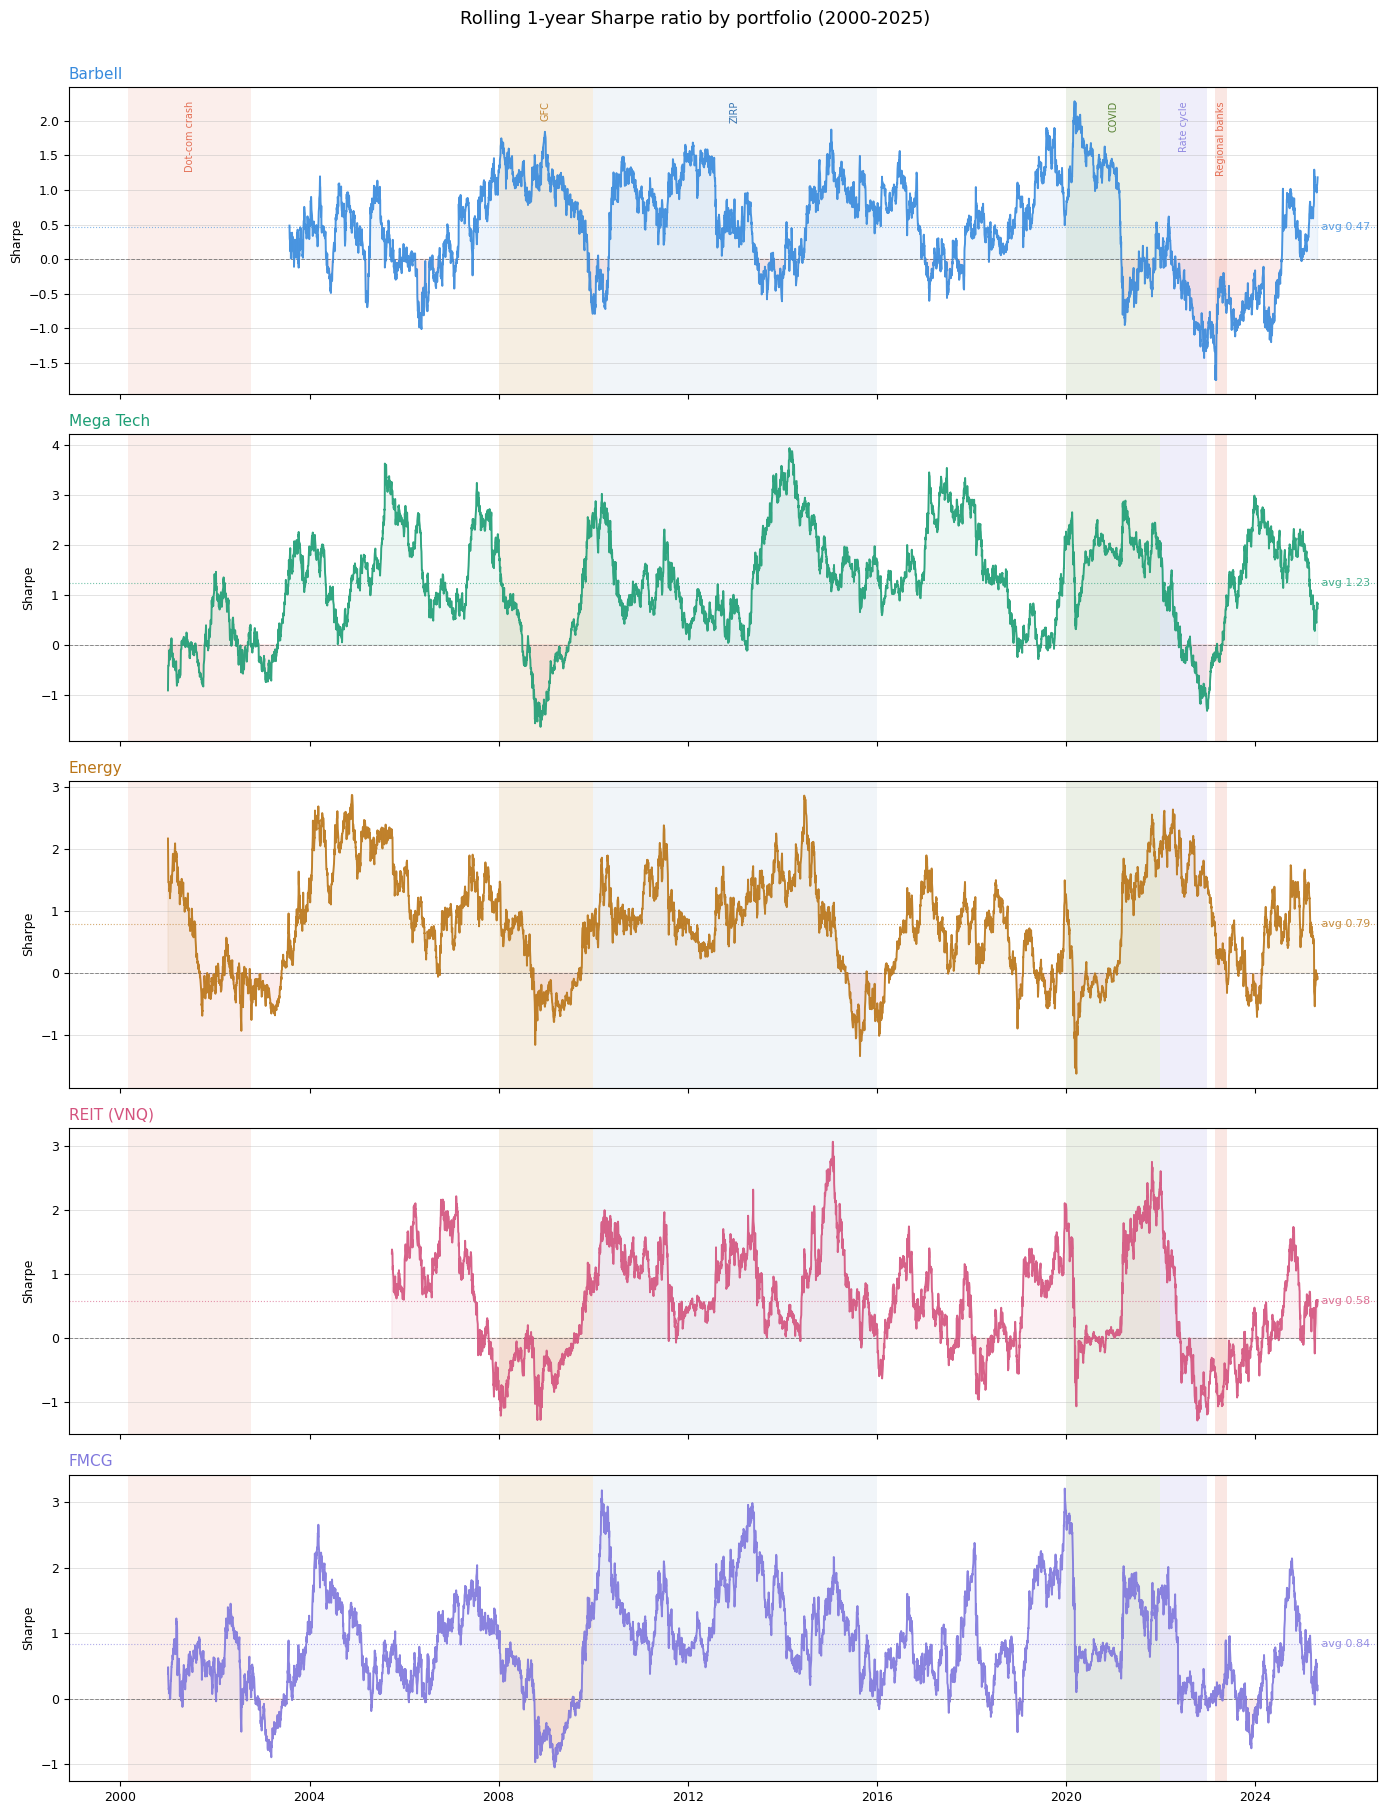

In [6]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

portfolios_ordered = ["Barbell", "Mega Tech", "Energy", "REIT (VNQ)", "FMCG"]

for ax, name in zip(axes, portfolios_ordered):
    series = sharpe_df[name].dropna()

    # Regime shading
    for label, start, end, color, alpha in REGIMES:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color=color, alpha=alpha, linewidth=0)

    # Zero line
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.4)

    # Portfolio line
    ax.plot(series.index, series.values,
            color=COLORS[name], linewidth=1.4, alpha=0.9)

    # Shade above/below zero for quick visual read
    ax.fill_between(series.index, series.values, 0,
                    where=(series.values >= 0),
                    color=COLORS[name], alpha=0.08)
    ax.fill_between(series.index, series.values, 0,
                    where=(series.values < 0),
                    color="#E24B4A", alpha=0.10)

    # Regime labels on top panel only to avoid repetition
    if name == "Barbell":
        ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 1 else 2.5
        for label, start, end, color, alpha in REGIMES:
            mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
            ax.text(mid, ymax * 0.92, label,
                    fontsize=7, color=color, ha="center", va="top",
                    rotation=90, alpha=0.85)

    # Panel title
    ax.set_title(name, fontsize=11, fontweight="normal",
                 loc="left", pad=6, color=COLORS[name])
    ax.set_ylabel("Sharpe", fontsize=9)
    ax.tick_params(axis="both", labelsize=9)
    ax.yaxis.grid(True, linewidth=0.5, alpha=0.5)
    ax.xaxis.grid(False)

    # Annotate full-period mean Sharpe
    mean_sr = series.mean()
    ax.axhline(mean_sr, color=COLORS[name], linewidth=0.8,
               linestyle=":", alpha=0.6)
    ax.text(series.index[-1], mean_sr, f" avg {mean_sr:.2f}",
            fontsize=8, color=COLORS[name], va="center", alpha=0.8)

axes[-1].set_xlabel("")
fig.suptitle("Rolling 1-year Sharpe ratio by portfolio (2000-2025)",
             fontsize=13, fontweight="normal", y=1.005)

fig.tight_layout()
plt.savefig("rolling_sharpe_individual.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:

# SPY from Yahoo
spy_prices  = yf.download("SPY", start="2000-01-01", end="2025-05-01")["Close"].squeeze().dropna()
spy_returns = spy_prices.pct_change().dropna()
spy_returns.name = "SPY"

# Mkt-Rf from Kenneth French Data Library -- daily factors
ff_daily        = pdr.get_data_famafrench("F-F_Research_Data_Factors_daily", start="2000-01-01")[0]
ff_daily.index  = pd.to_datetime(ff_daily.index, format="%Y%m%d")
mktrf_returns   = ff_daily["Mkt-RF"] / 100
mktrf_returns.name = "Mkt-RF"

BENCHMARKS = {
    "SPY"    : spy_returns,
    "Mkt-RF" : mktrf_returns,
}

BENCHMARK_COLORS = {
    "SPY"    : "#888780",
    "Mkt-RF" : "#444441",
}

BENCHMARK_DASHES = {
    "SPY"    : (4, 2),
    "Mkt-RF" : (2, 2),
}

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_416534/3577873941.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_daily        = pdr.get_data_famafrench("F-F_Research_Data_Factors_daily", start="2000-01-01")[0]


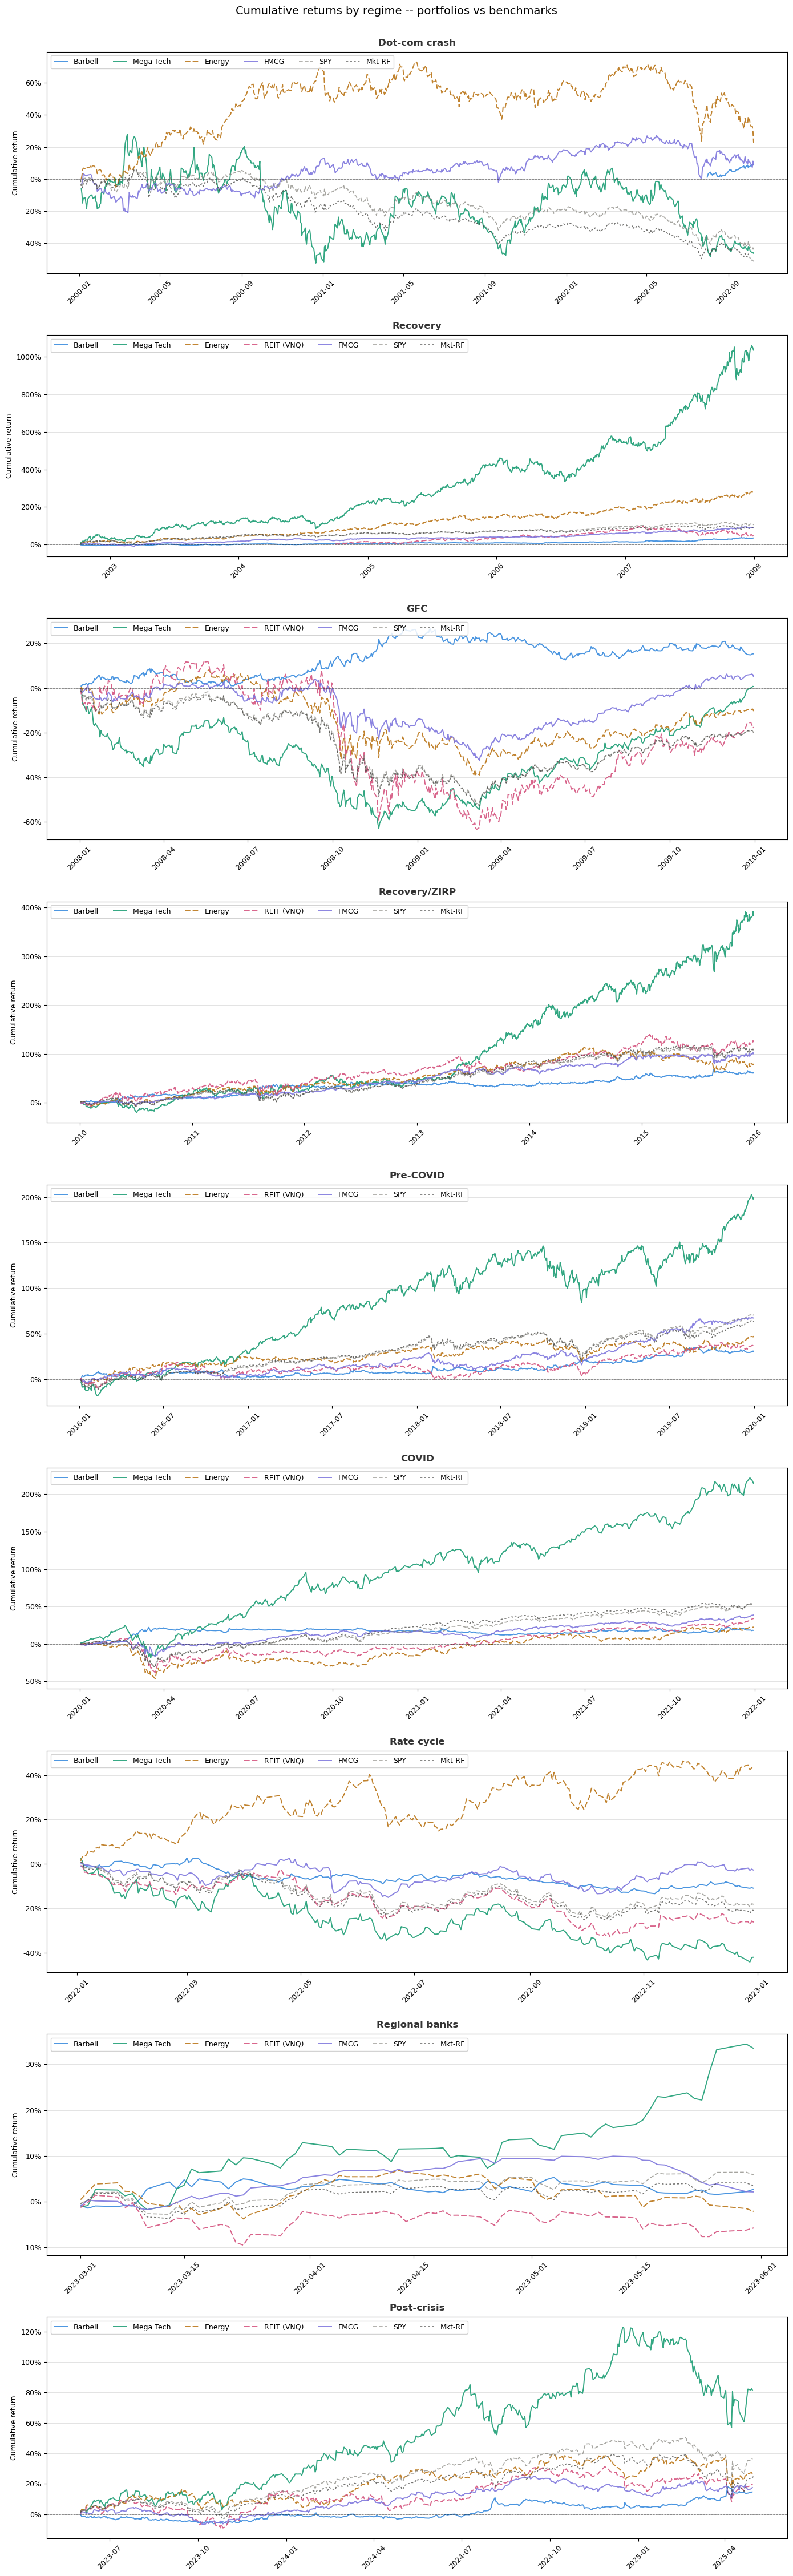

In [9]:
from matplotlib.ticker import FuncFormatter

# Dict version for the cumulative returns plots
REGIMES_DICT = {
    "Dot-com crash" : ("2000-01-01", "2002-10-09"),
    "Recovery"      : ("2002-10-10", "2007-12-31"),
    "GFC"           : ("2008-01-01", "2009-12-31"),
    "Recovery/ZIRP" : ("2010-01-01", "2015-12-31"),
    "Pre-COVID"     : ("2016-01-01", "2019-12-31"),
    "COVID"         : ("2020-01-01", "2021-12-31"),
    "Rate cycle"    : ("2022-01-01", "2022-12-31"),
    "Regional banks": ("2023-03-01", "2023-05-31"),
    "Post-crisis"   : ("2023-06-01", "2025-05-01"),
}
pct_fmt = FuncFormatter(lambda x, _: f"{x:.0f}%")

fig, axes = plt.subplots(len(REGIMES_DICT), 1,
                         figsize=(14, 5 * len(REGIMES_DICT)), sharex=False)

for ax, (regime_label, (start, end)) in zip(axes, REGIMES_DICT.items()):
    any_plotted = False

    # Portfolio lines
    for name, (ret, _) in portfolios.items():
        pr = ret.loc[start:end].dropna()
        if len(pr) < 5:
            continue
        cum = ((1 + pr).cumprod() - 1) * 100
        ax.plot(cum.index, cum,
                color=COLORS[name], linewidth=1.4,
                dashes=DASHES.get(name, (1, 0)),
                label=name, alpha=0.9)
        any_plotted = True

    # Benchmark lines
    for bname, bret in BENCHMARKS.items():
        br = bret.loc[start:end].dropna()
        if len(br) < 5:
            continue
        bcum = ((1 + br).cumprod() - 1) * 100
        ax.plot(bcum.index, bcum,
                color=BENCHMARK_COLORS[bname], linewidth=1.2,
                dashes=BENCHMARK_DASHES[bname],
                label=bname, alpha=0.75)
        any_plotted = True

    ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(pct_fmt)
    ax.set_title(regime_label, fontsize=12, fontweight="bold",
                 color="#333333", pad=8)
    ax.set_ylabel("Cumulative return", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.yaxis.grid(True, linewidth=0.5, alpha=0.5)
    ax.xaxis.grid(False)

    if any_plotted:
        ax.legend(loc="upper left", fontsize=9, framealpha=0.85,
                  ncol=len(portfolios) + len(BENCHMARKS))
    else:
        ax.text(0.5, 0.5, "No data for this regime",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=10, color="grey")

fig.suptitle("Cumulative returns by regime -- portfolios vs benchmarks",
             fontsize=14, fontweight="normal", y=1.002)
fig.tight_layout()
plt.savefig("cumulative_returns_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()

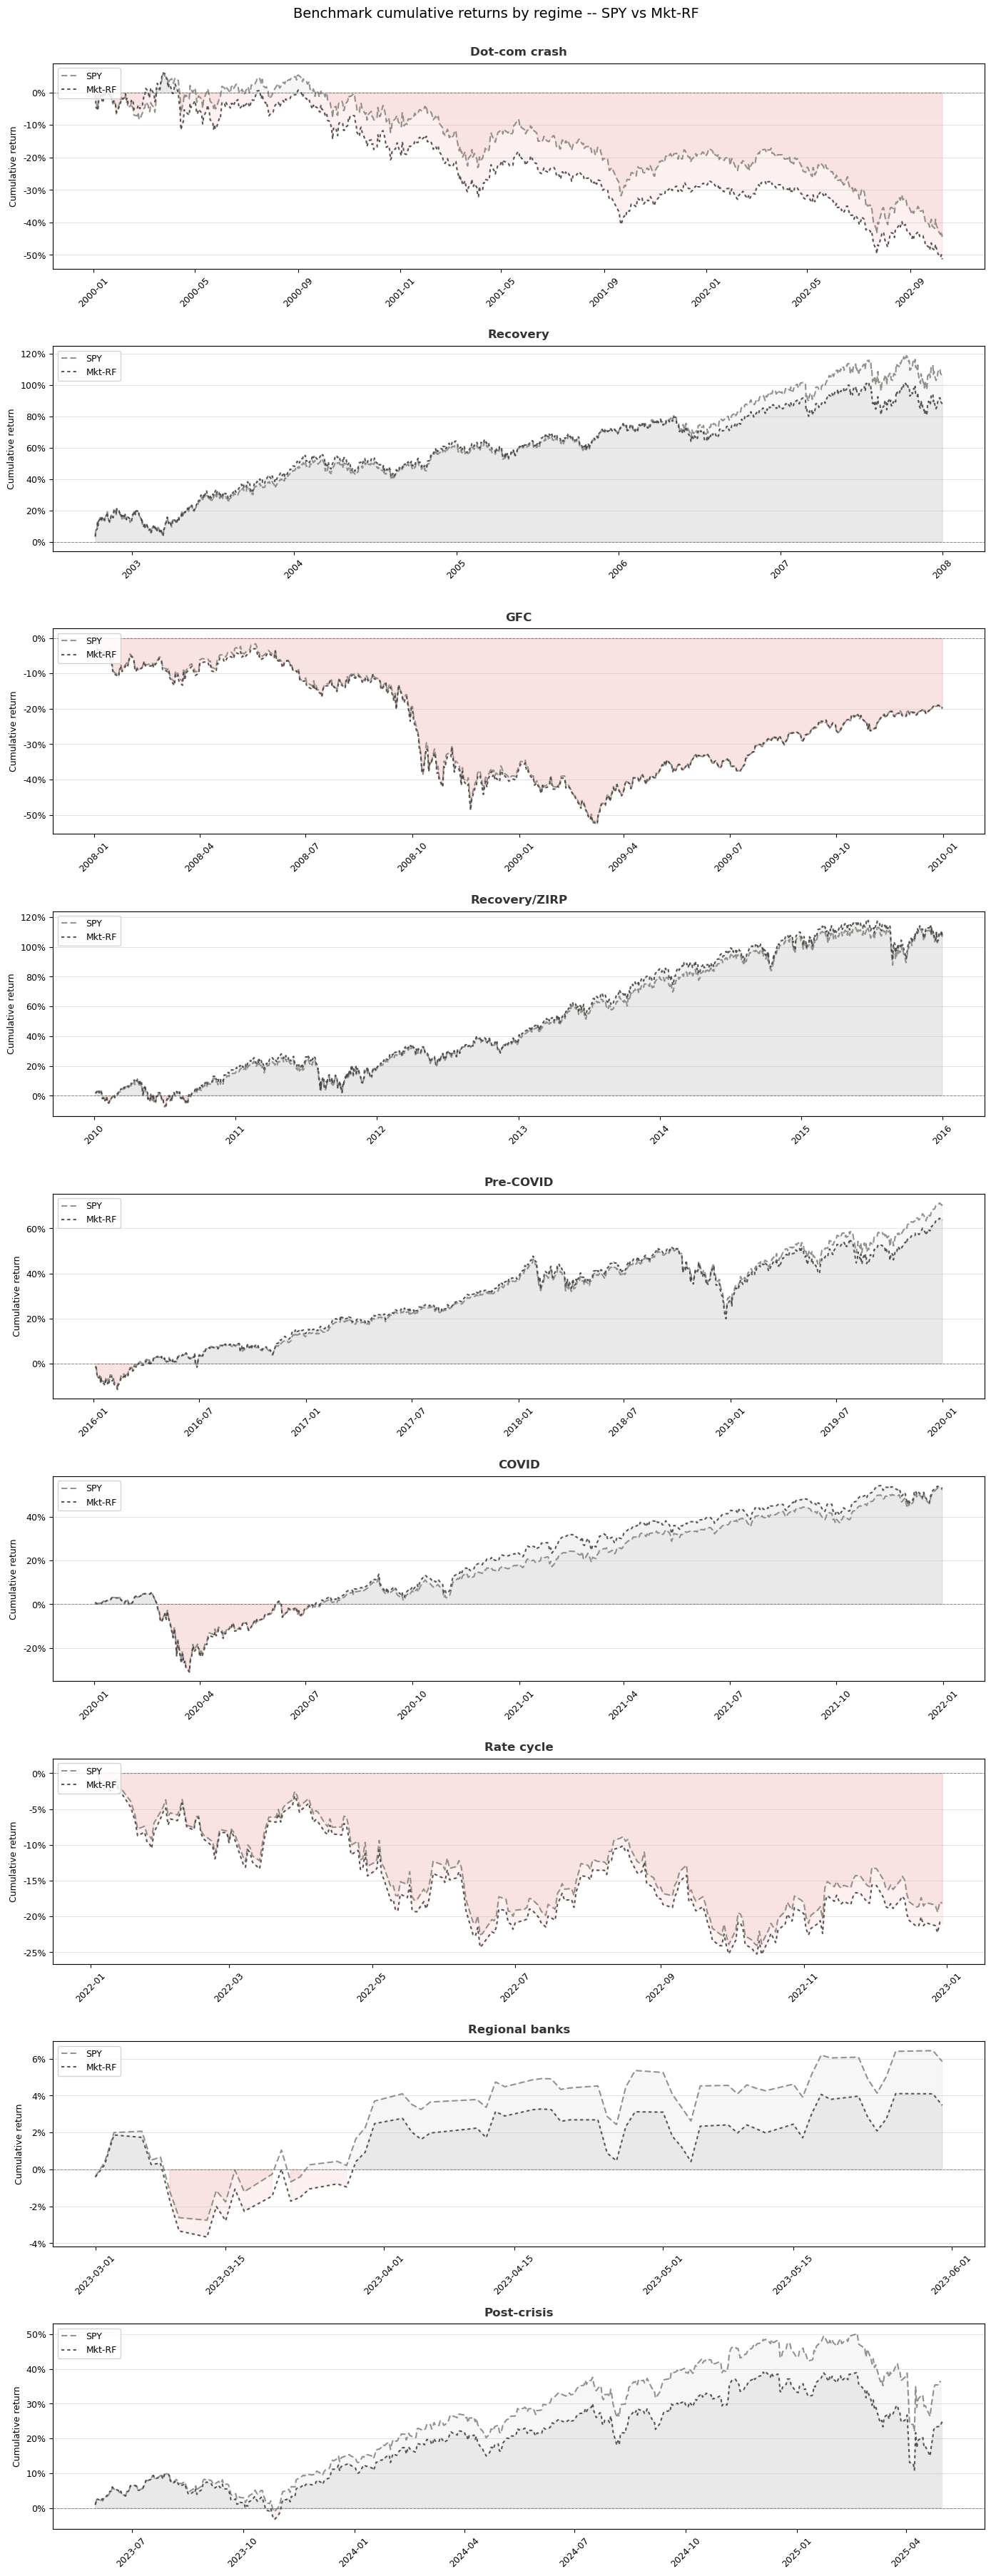

In [10]:
fig, axes = plt.subplots(len(REGIMES_DICT), 1,
                         figsize=(14, 4 * len(REGIMES_DICT)), sharex=False)

for ax, (regime_label, (start, end)) in zip(axes, REGIMES_DICT.items()):
    any_plotted = False

    for bname, bret in BENCHMARKS.items():
        br = bret.loc[start:end].dropna()
        if len(br) < 5:
            continue
        bcum = ((1 + br).cumprod() - 1) * 100
        ax.plot(bcum.index, bcum,
                color=BENCHMARK_COLORS[bname], linewidth=1.5,
                dashes=BENCHMARK_DASHES[bname],
                label=bname, alpha=0.9)

        # Shade above/below zero
        ax.fill_between(bcum.index, bcum.values, 0,
                        where=(bcum.values >= 0),
                        color=BENCHMARK_COLORS[bname], alpha=0.07)
        ax.fill_between(bcum.index, bcum.values, 0,
                        where=(bcum.values < 0),
                        color="#E24B4A", alpha=0.08)
        any_plotted = True

    ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(pct_fmt)
    ax.set_title(regime_label, fontsize=12, fontweight="bold",
                 color="#333333", pad=8)
    ax.set_ylabel("Cumulative return", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.yaxis.grid(True, linewidth=0.5, alpha=0.5)
    ax.xaxis.grid(False)

    if any_plotted:
        ax.legend(loc="upper left", fontsize=9, framealpha=0.85)
    else:
        ax.text(0.5, 0.5, "No data for this regime",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=10, color="grey")

fig.suptitle("Benchmark cumulative returns by regime -- SPY vs Mkt-RF",
             fontsize=14, fontweight="normal", y=1.002)
fig.tight_layout()
plt.savefig("benchmark_returns_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()